# Adult Census Income Classification

This notebook presents an end-to-end Machine Learning pipeline to predict whether an individual's income exceeds $50,000 per year based on census features. We will use the **Adult Census Income dataset** from the UCI Machine Learning Repository.

## Structure of the Notebook:
1. **Environment Setup & Data Loading**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing & Pipeline Construction**
4. **Model Training & Initial Comparison**
5. **Hyperparameter Tuning**
6. **Model Evaluation & Visualizations**
7. **Saving the Pipeline**

## 1. Environment Setup & Data Loading

First, we install/import the required libraries. We will import pandas, numpy, matplotlib, seaborn, scikit-learn, and xgboost.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src/ directory to the path so we can import modules
sys.path.append(os.path.abspath('../src'))

from data_loader import load_and_clean_data
from utils import plot_confusion_matrix, plot_roc_curves, plot_feature_importance

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Load Dataset
Let's load the training and test sets using our helper function in `data_loader.py` which downloads the files if they are not cached.

In [2]:
train_df, test_df = load_and_clean_data("../data")
print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

Training data already exists locally.
Test data already exists locally.


Train dataset shape: (32561, 16)


Test dataset shape: (16281, 16)


Let's print the first few rows of the training dataset:

In [3]:
train_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_bin
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


Let's check the schema and types of features:

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income          32561 non-null  str  
 15  income_bin      32561 non-null  int64
dtypes: int64(7), str(9)
memory usage: 4.0 MB


Check basic statistics of numerical columns:

In [5]:
train_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income_bin
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456,0.240810
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429,0.427581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


## 2. Exploratory Data Analysis (EDA)

### Target Variable Distribution
Let's see if the class label is balanced.

C:\Users\soumi\AppData\Local\Temp\ipykernel_33588\2420192303.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='income', palette='viridis', ax=ax)


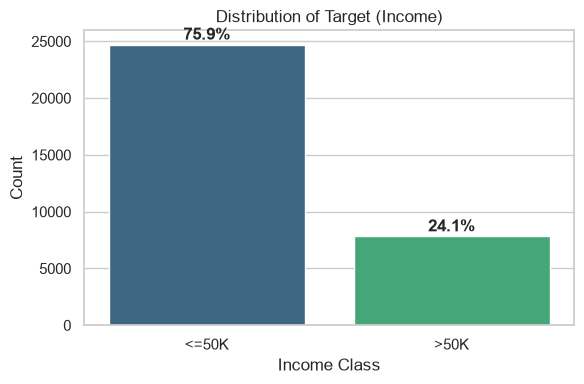

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train_df, x='income', palette='viridis', ax=ax)
plt.title('Distribution of Target (Income)')
plt.ylabel('Count')
plt.xlabel('Income Class')

# Show percentages
total = len(train_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 200), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')

plt.tight_layout()
plt.show()

**Observation**: The dataset is heavily imbalanced, with roughly 76% of individuals earning `<=50K` and only 24% earning `>50K`. We will need to take this class imbalance into account when building models (e.g. using `class_weight='balanced'` or stratified CV).

### Numerical Features Analysis
Let's look at the correlation matrix of numerical variables.

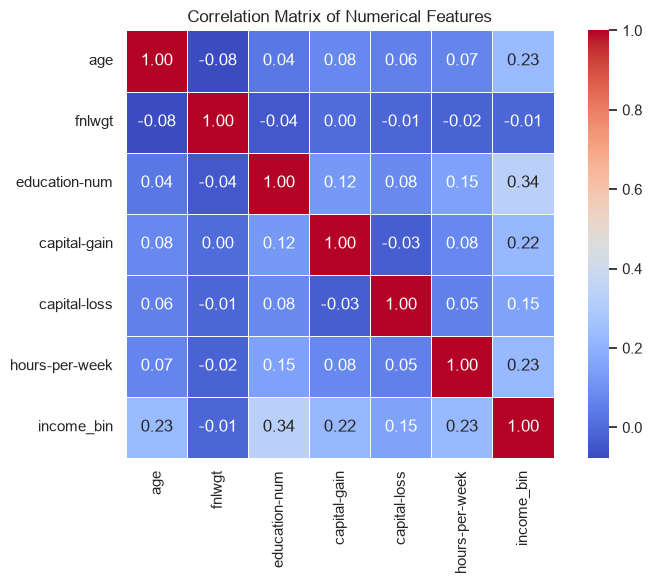

In [7]:
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
corr_matrix = train_df[num_cols + ['income_bin']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

**Observation**: `education-num`, `age`, `hours-per-week`, and `capital-gain` have the highest positive correlation with `income_bin`. `fnlwgt` (final weight) shows close to zero correlation and is likely not very predictive.

### Age Distribution by Income
Let's see if age plays a significant role in income levels.

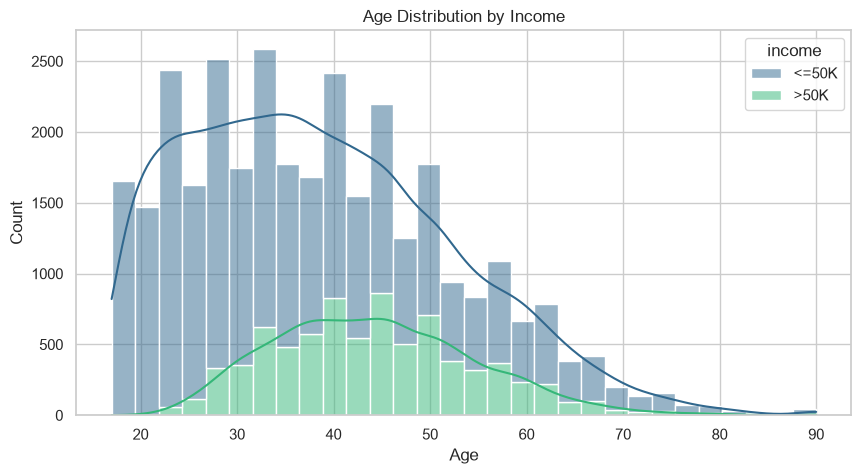

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='age', hue='income', kde=True, bins=30, multiple='stack', palette='viridis')
plt.title('Age Distribution by Income')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Observation**: The proportion of individuals earning `>50K` peaks between the ages of 35 and 55. Younger individuals (under 25) rarely earn `>50K`.

### Education Num vs Income
Let's see if more years of education relates directly to higher income.

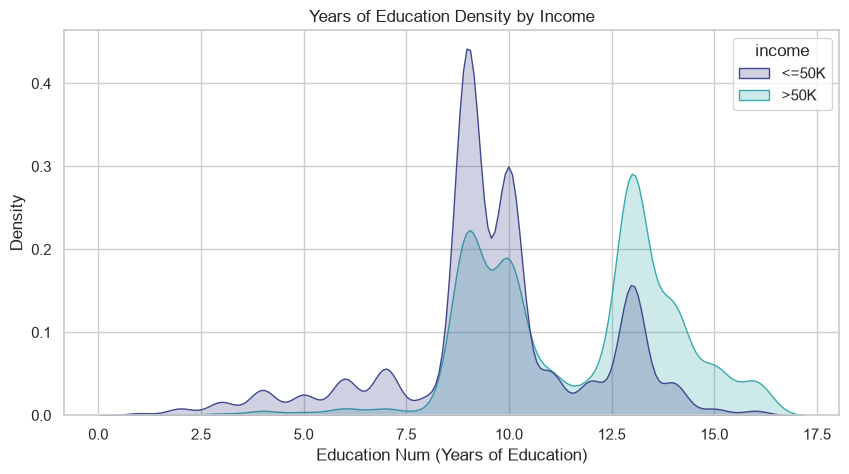

In [9]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train_df, x='education-num', hue='income', fill=True, common_norm=False, palette='mako')
plt.title('Years of Education Density by Income')
plt.xlabel('Education Num (Years of Education)')
plt.ylabel('Density')
plt.show()

**Observation**: Individuals with higher education years (specifically > 12 years, corresponding to Bachelor's, Master's, Doctorate) have a much higher likelihood of earning `>50K`.

### Categorical Features Analysis
Let's analyze the relationship between categorical features (`workclass`, `sex`, `marital-status`, `occupation`) and income.

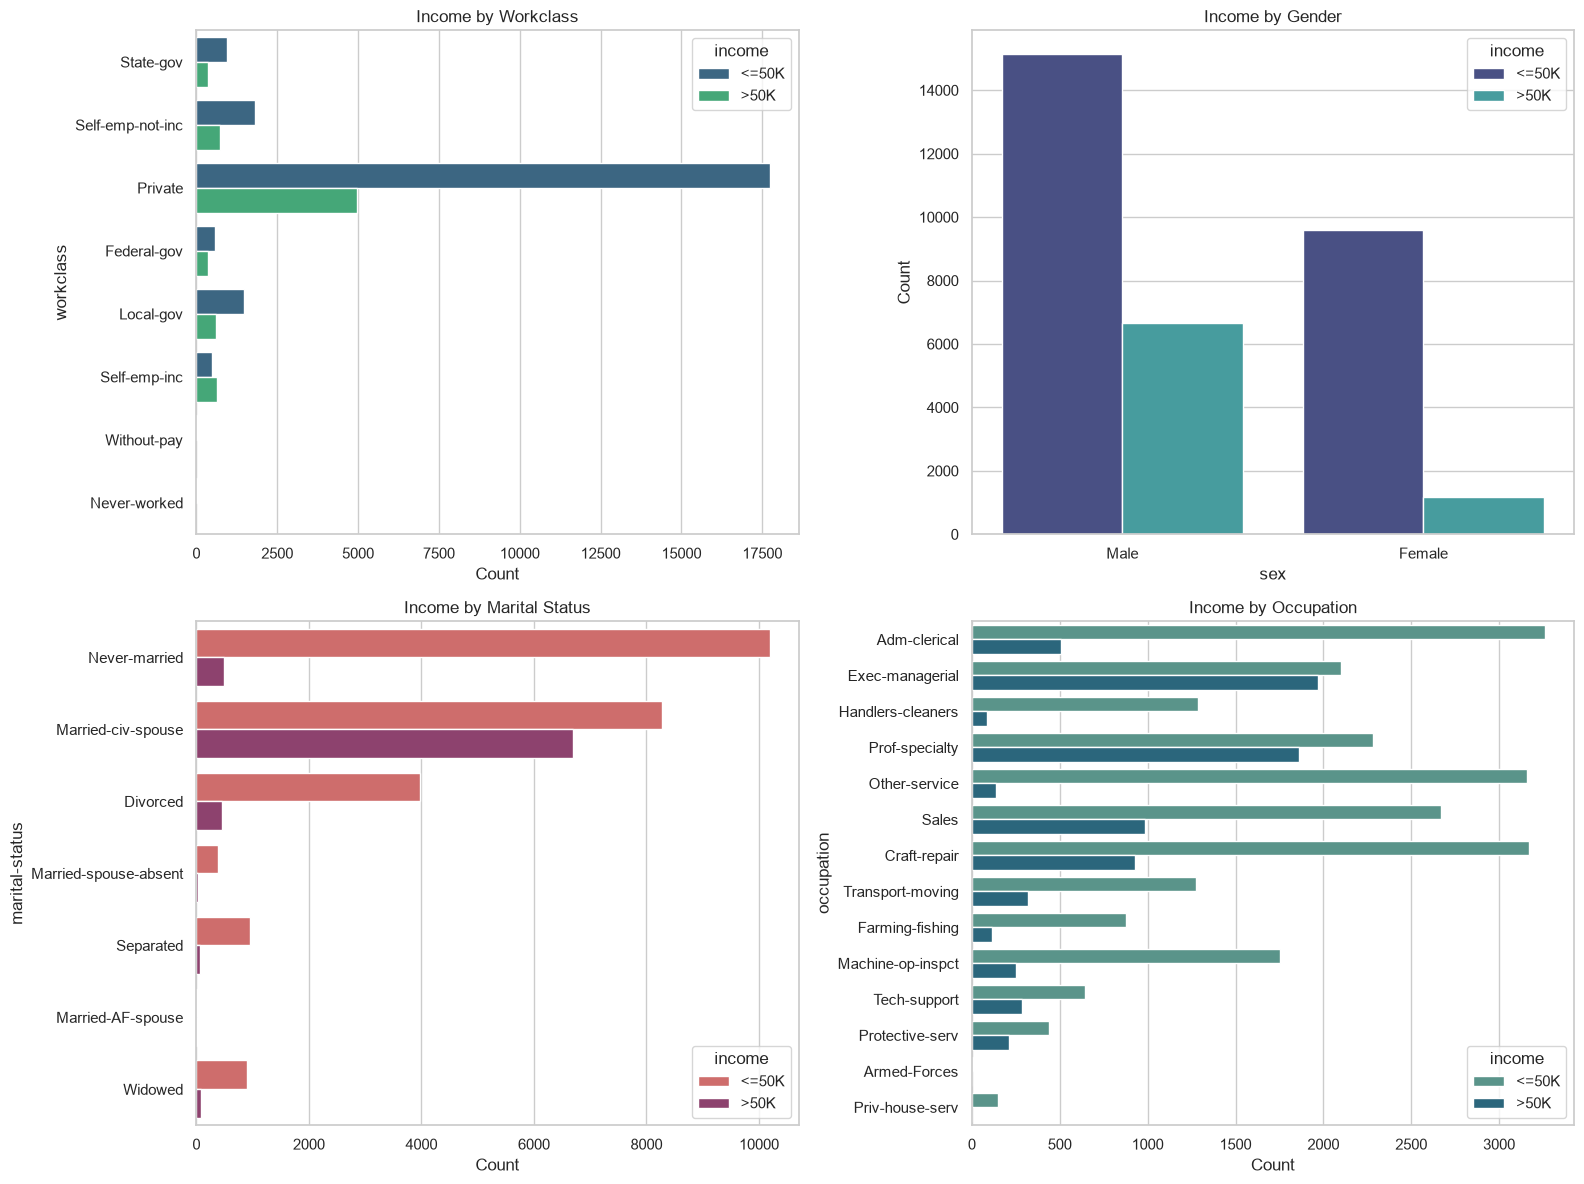

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Workclass
sns.countplot(data=train_df, y='workclass', hue='income', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Income by Workclass')
axes[0, 0].set_xlabel('Count')

# Sex
sns.countplot(data=train_df, x='sex', hue='income', palette='mako', ax=axes[0, 1])
axes[0, 1].set_title('Income by Gender')
axes[0, 1].set_ylabel('Count')

# Marital Status
sns.countplot(data=train_df, y='marital-status', hue='income', palette='flare', ax=axes[1, 0])
axes[1, 0].set_title('Income by Marital Status')
axes[1, 0].set_xlabel('Count')

# Occupation
sns.countplot(data=train_df, y='occupation', hue='income', palette='crest', ax=axes[1, 1])
axes[1, 1].set_title('Income by Occupation')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

**Observations**:
- **Workclass**: The private sector employs the vast majority of individuals.
- **Gender**: A higher proportion of males earn `>50K` compared to females in this dataset.
- **Marital Status**: Individuals who are "Married-civ-spouse" have a significantly higher rate of earning `>50K` compared to other categories.
- **Occupation**: Professional specialty and Executive/Managerial roles have the highest density of `>50K` earners.

## 3. Data Preprocessing & Pipeline Construction

We will build a preprocessing pipeline using `scikit-learn`'s `ColumnTransformer`. 
- For **numerical** columns, we impute missing values with the median and scale using `RobustScaler` (handles outliers in capital gain/loss).
- For **categorical** columns, we impute with the most frequent value (mode) and encode using `OneHotEncoder`.
- We drop the column `education` because it is redundant with `education-num`.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Define features and target
target_col = 'income_bin'
exclude_cols = ['income', 'income_bin', 'education']
feature_cols = [col for col in train_df.columns if col not in exclude_cols]

numerical_cols = train_df[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_df[feature_cols].select_dtypes(include=['object']).columns.tolist()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Construct Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

# Fit preprocessor and transform features
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Extract feature names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
try:
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
except AttributeError:
    cat_feature_names = cat_encoder.get_feature_names(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_feature_names

print(f"X_train shape after processing: {X_train_proc.shape}")

X_train shape after processing: (32561, 89)


C:\Users\soumi\AppData\Local\Temp\ipykernel_33588\1151579736.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df[feature_cols].select_dtypes(include=['object']).columns.tolist()


## 4. Model Training & Initial Comparison

We will train three different algorithms:
1. **Logistic Regression** (Linear baseline)
2. **Random Forest Classifier** (Tree-based ensemble)
3. **XGBoost Classifier** (Gradient boosting ensemble)

We'll adjust class weights or settings to handle the imbalance where possible.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

trained_models = {}
metrics = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_proc, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_proc)
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    
    metrics.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC-AUC": auc_score
    })
    
    print(f"--- {name} Results ---")
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | ROC-AUC: {auc_score:.4f}")
    print(classification_report(y_test, y_pred))
    print("\n")
    
metrics_df = pd.DataFrame(metrics)
print("=== Summary of Initial Performance ===")
print(metrics_df)

Training Logistic Regression...


C:\Users\soumi\.gemini\antigravity\scratch\adult-census-income-classification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression Results ---
Accuracy: 0.8037 | F1-Score: 0.6696 | ROC-AUC: 0.9036
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     12435
           1       0.56      0.84      0.67      3846

    accuracy                           0.80     16281
   macro avg       0.75      0.82      0.76     16281
weighted avg       0.85      0.80      0.82     16281



Training Random Forest...


--- Random Forest Results ---
Accuracy: 0.8127 | F1-Score: 0.6854 | ROC-AUC: 0.9144
              precision    recall  f1-score   support

           0       0.95      0.80      0.87     12435
           1       0.57      0.86      0.69      3846

    accuracy                           0.81     16281
   macro avg       0.76      0.83      0.78     16281
weighted avg       0.86      0.81      0.82     16281



Training XGBoost...


C:\Users\soumi\.gemini\antigravity\scratch\adult-census-income-classification\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:51:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Results ---
Accuracy: 0.8740 | F1-Score: 0.7083 | ROC-AUC: 0.9285
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     12435
           1       0.78      0.65      0.71      3846

    accuracy                           0.87     16281
   macro avg       0.84      0.80      0.81     16281
weighted avg       0.87      0.87      0.87     16281



=== Summary of Initial Performance ===
                 Model  Accuracy  F1-Score   ROC-AUC
0  Logistic Regression  0.803698  0.669630  0.903631
1        Random Forest  0.812665  0.685437  0.914359
2              XGBoost  0.874025  0.708292  0.928547


## 5. Hyperparameter Tuning

Let's optimize our best model (XGBoost) using `RandomizedSearchCV` to fine-tune the parameters and get even better performance.

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3] # To help with class imbalance
}

xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

print("Starting RandomizedSearchCV for XGBoost...")
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_proc, y_train)

print(f"Best F1-Score on CV: {xgb_search.best_score_:.4f}")
print(f"Best Parameters: {xgb_search.best_params_}")

Starting RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\soumi\.gemini\antigravity\scratch\adult-census-income-classification\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:52:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best F1-Score on CV: 0.7225
Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 3, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


Let's evaluate the tuned XGBoost model on the test set:

In [14]:
best_xgb = xgb_search.best_estimator_
trained_models["Tuned XGBoost"] = best_xgb

y_pred_tuned = best_xgb.predict(X_test_proc)
y_prob_tuned = best_xgb.predict_proba(X_test_proc)[:, 1]

acc_t = accuracy_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)
auc_t = roc_auc_score(y_test, y_prob_tuned)

print("--- Tuned XGBoost Results ---")
print(f"Accuracy: {acc_t:.4f} | F1-Score: {f1_t:.4f} | ROC-AUC: {auc_t:.4f}")
print(classification_report(y_test, y_pred_tuned))

--- Tuned XGBoost Results ---
Accuracy: 0.8380 | F1-Score: 0.7126 | ROC-AUC: 0.9281
              precision    recall  f1-score   support

           0       0.95      0.83      0.89     12435
           1       0.61      0.85      0.71      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.84      0.80     16281
weighted avg       0.87      0.84      0.85     16281



## 6. Model Evaluation & Visualizations

### Confusion Matrix Comparison
Let's plot confusion matrices for our classifiers.

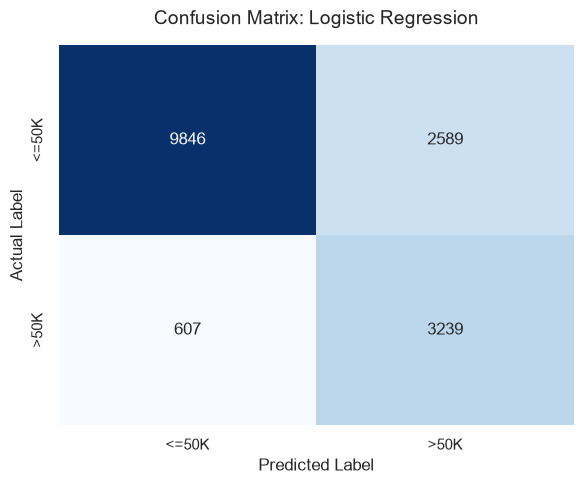

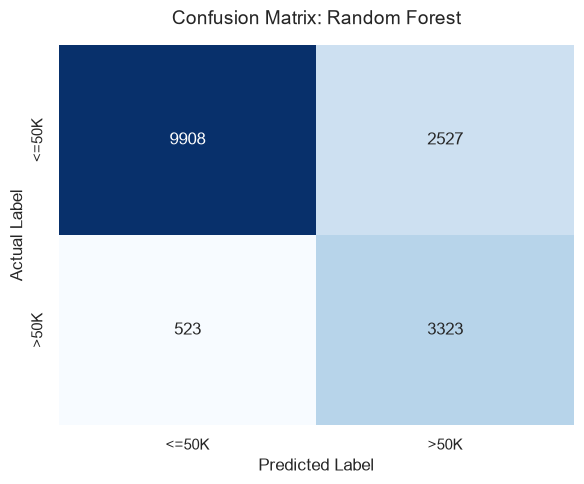

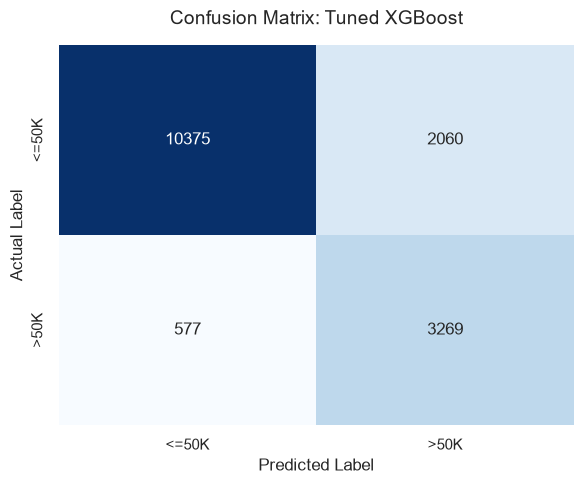

In [15]:
for model_name in ["Logistic Regression", "Random Forest", "Tuned XGBoost"]:
    plot_confusion_matrix(y_test, trained_models[model_name].predict(X_test_proc), title=f"Confusion Matrix: {model_name}")
    plt.show()

### ROC Curves
Let's plot ROC-AUC curves for all models side-by-side to visually compare performance.

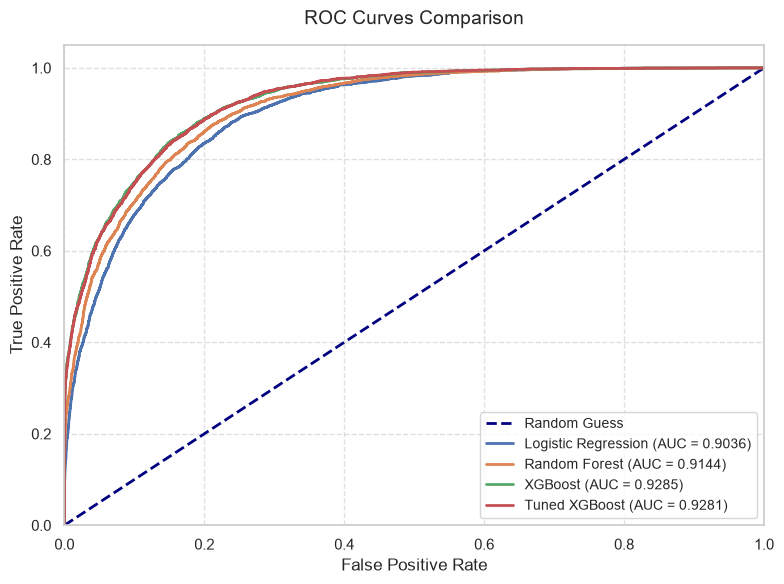

In [16]:
plot_roc_curves(trained_models, X_test_proc, y_test, title="ROC Curves Comparison")
plt.show()

### Feature Importance
Let's inspect the feature importance of our Tuned XGBoost model to find which variables drive the prediction.

C:\Users\soumi\.gemini\antigravity\scratch\adult-census-income-classification\src\utils.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette=colors, ax=ax)


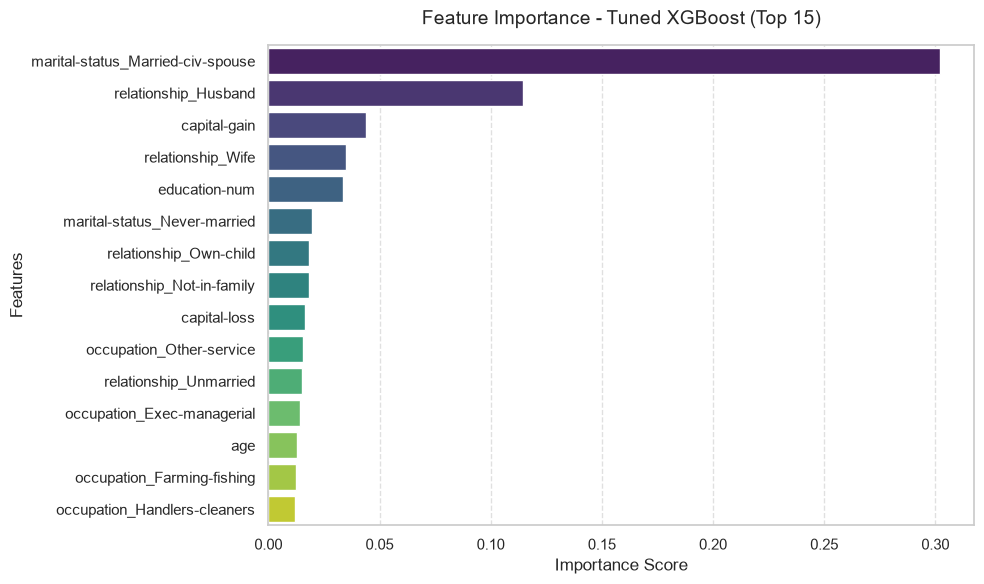

In [17]:
xgb_importances = best_xgb.feature_importances_
plot_feature_importance(all_feature_names, xgb_importances, title="Feature Importance - Tuned XGBoost", top_n=15)
plt.show()

**Observation**: The top features predicting higher income are **marital-status (Married-civ-spouse)**, **capital-gain**, **education-num** (years of education), and **relationship (husband)**. These align well with our EDA findings.

## 7. Saving the Pipeline

We'll serialize the best performing model pipeline (preprocessor + Tuned XGBoost Classifier) so it can be easily deployed in production.

In [18]:
import joblib

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_xgb)
])

# Save
model_file = "../models/best_income_classifier_pipeline.joblib"
os.makedirs("../models", exist_ok=True)
joblib.dump(full_pipeline, model_file)
print(f"Full end-to-end model pipeline saved successfully to {model_file}!")

Full end-to-end model pipeline saved successfully to ../models/best_income_classifier_pipeline.joblib!
